# Player $\theta$ evaluation

Held-out **action prediction** with vs without per-player tilt $\hat\theta$ from `artifacts/player_thetas_<em|newton>.json` (suffix set by `THETA_OPTIMIZER` in the setup cell).

**Splits:** `sessions_theta.txt` (EM) and `sessions_filter.txt` (online). Helpers: `utils.eval.player_thetas_evaluation_helpers`, `utils.eval.common`.


In [18]:
from __future__ import annotations

import sys
from pathlib import Path

def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for x in (p, *p.parents):
        if (x / "runners" / "common.py").is_file():
            return x
    raise FileNotFoundError("Run from inside the repo (runners/common.py not found).")

REPO = _find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# Artifacts tag: must match `artifacts/player_thetas_<tag>.json` from find_theta ("em" or "newton").
THETA_OPTIMIZER = "newton"

import json

import matplotlib.pyplot as plt
import numpy as np

from utils.eval.common import em_and_online_refs
from utils.eval.player_thetas_evaluation_helpers import (
    load_global_betas,
    load_player_thetas,
    build_player_prediction_dict,
    flip_rate,
    realised_shifts,
    heldout_gradient_norm_components,
    online_summary_rows,
    nll,
    mean_brier,
)

priors = json.loads((REPO / "artifacts" / "global_priors.json").read_text())
BETA_PRE, BETA_FACING, BETA_NO_BET = load_global_betas(priors)
thetas_payload = json.loads(
    (REPO / "artifacts" / f"player_thetas_{THETA_OPTIMIZER}.json").read_text()
)
PLAYERS, THETA_PRE, THETA_POST = load_player_thetas(thetas_payload)
print("players:", PLAYERS)
print("THETA_OPTIMIZER:", THETA_OPTIMIZER)


players: ['MrBlue', 'Bill', 'Pluribus']


In [19]:
em_refs, online_refs, em_s, online_s = em_and_online_refs(REPO)
print("theta sessions:", em_s)
print("filter sessions:", online_s)
print("hands em", len(em_refs), "online", len(online_refs))

theta sessions: ['40', '41', '42', '44', '91', '92']
filter sessions: ['40b', '42b', '44b', '64', '72', '90', '94b', '95', '95b']
hands em 541 online 1015


In [20]:
PRED = build_player_prediction_dict(
    PLAYERS,
    B_pre=BETA_PRE,
    B_facing=BETA_FACING,
    B_no_bet=BETA_NO_BET,
    theta_pre=THETA_PRE,
    theta_post=THETA_POST,
    em_refs=em_refs,
    online_refs=online_refs,
)
print("buckets", len(PRED))

buckets 18


In [21]:
print(f"{'player':<10} {'split':<7} {'head':<8} {'N':>4} {'NLL_0':>8} {'NLL_θ':>8} {'Δ':>8}")
for (p, sp, head), (P0, Pt, y) in sorted(PRED.items()):
    n0, nt = nll(P0, y), nll(Pt, y)
    print(f"{p:<10} {sp:<7} {head:<8} {y.size:>4} {n0:>8.4f} {nt:>8.4f} {n0-nt:>+8.4f}")

player     split   head        N    NLL_0    NLL_θ        Δ
Bill       em      facing     81   0.7160   0.7122  +0.0038
Bill       em      no_bet    189   0.6078   0.6071  +0.0007
Bill       em      preflop   565   0.6027   0.6001  +0.0025
Bill       online  facing    149   0.7256   0.7202  +0.0054
Bill       online  no_bet    393   0.5600   0.5598  +0.0002
Bill       online  preflop  1037   0.5668   0.5623  +0.0045
MrBlue     em      facing     97   0.7407   0.7337  +0.0070
MrBlue     em      no_bet    222   0.5092   0.5095  -0.0003
MrBlue     em      preflop   560   0.6316   0.6263  +0.0054
MrBlue     online  facing    204   0.7436   0.7498  -0.0061
MrBlue     online  no_bet    484   0.4892   0.4796  +0.0096
MrBlue     online  preflop  1050   0.6674   0.6533  +0.0141
Pluribus   em      facing     61   0.8060   0.8071  -0.0012
Pluribus   em      no_bet    188   0.5993   0.5958  +0.0036
Pluribus   em      preflop   566   0.5842   0.5804  +0.0038
Pluribus   online  facing    117   0.781

In [22]:
print(f"{'player':<10} {'split':<7} {'head':<8} {'N':>4} {'Brier_0':>9} {'Brier_θ':>9} {'Δ':>9}")
for (p, sp, head), (P0, Pt, y) in sorted(PRED.items()):
    b0, bt = mean_brier(P0, y), mean_brier(Pt, y)
    print(f"{p:<10} {sp:<7} {head:<8} {y.size:>4} {b0:>9.4f} {bt:>9.4f} {b0-bt:>+9.4f}")

player     split   head        N   Brier_0   Brier_θ         Δ
Bill       em      facing     81    0.4135    0.4098   +0.0037
Bill       em      no_bet    189    0.4199    0.4193   +0.0006
Bill       em      preflop   565    0.3376    0.3368   +0.0007
Bill       online  facing    149    0.4310    0.4238   +0.0072
Bill       online  no_bet    393    0.3796    0.3791   +0.0005
Bill       online  preflop  1037    0.3120    0.3107   +0.0013
MrBlue     em      facing     97    0.4522    0.4555   -0.0033
MrBlue     em      no_bet    222    0.3358    0.3399   -0.0041
MrBlue     em      preflop   560    0.3570    0.3531   +0.0039
MrBlue     online  facing    204    0.4394    0.4476   -0.0082
MrBlue     online  no_bet    484    0.3137    0.3087   +0.0050
MrBlue     online  preflop  1050    0.3822    0.3725   +0.0097
Pluribus   em      facing     61    0.4912    0.4912   -0.0001
Pluribus   em      no_bet    188    0.4169    0.4130   +0.0039
Pluribus   em      preflop   566    0.3229    0.3264   

In [6]:
print(f"{'player':<10} {'split':<7} {'head':<8} {'N':>4} {'acc_0':>7} {'acc_θ':>7} {'flips':>7}")
for (p, sp, head), (P0, Pt, y) in sorted(PRED.items()):
    acc0 = float((P0.argmax(axis=1) == y.astype(int)).mean()) if y.size else float("nan")
    acct = float((Pt.argmax(axis=1) == y.astype(int)).mean()) if y.size else float("nan")
    print(f"{p:<10} {sp:<7} {head:<8} {y.size:>4} {acc0:>7.3f} {acct:>7.3f} {flip_rate(P0, Pt):>7.3f}")

player     split   head        N   acc_0   acc_θ   flips
Bill       em      facing     81   0.753   0.778   0.049
Bill       em      no_bet    189   0.672   0.672   0.000
Bill       em      preflop   565   0.722   0.733   0.019
Bill       online  facing    149   0.691   0.705   0.013
Bill       online  no_bet    393   0.710   0.718   0.008
Bill       online  preflop  1037   0.748   0.753   0.009
MrBlue     em      facing     97   0.660   0.608   0.093
MrBlue     em      no_bet    222   0.761   0.739   0.041
MrBlue     em      preflop   560   0.698   0.707   0.027
MrBlue     online  facing    204   0.686   0.647   0.078
MrBlue     online  no_bet    484   0.798   0.779   0.043
MrBlue     online  preflop  1050   0.671   0.680   0.011
Pluribus   em      facing     61   0.623   0.590   0.066
Pluribus   em      no_bet    188   0.617   0.617   0.021
Pluribus   em      preflop   566   0.753   0.744   0.014
Pluribus   online  facing    117   0.701   0.701   0.017
Pluribus   online  no_bet    37

In [7]:
shift_arrays = {k: realised_shifts(P0, Pt, y) for k, (P0, Pt, y) in PRED.items()}
print(f"{'player':<10} {'split':<7} {'head':<8} {'N':>4} {'mean|Δ|':>9} {'median|Δ|':>11}")
for (p, sp, head), (P0, Pt, y) in sorted(PRED.items()):
    s = shift_arrays[(p, sp, head)]
    if s.size == 0:
        print(f"{p:<10} {sp:<7} {head:<8} {0:>4}")
        continue
    print(f"{p:<10} {sp:<7} {head:<8} {s.size:>4} {s.mean():>9.4f} {np.median(s):>11.4f}")

player     split   head        N   mean|Δ|   median|Δ|
Bill       em      facing     81    0.0285      0.0296
Bill       em      no_bet    189    0.0051      0.0052
Bill       em      preflop   565    0.0162      0.0128
Bill       online  facing    149    0.0291      0.0301
Bill       online  no_bet    393    0.0051      0.0054
Bill       online  preflop  1037    0.0158      0.0116
MrBlue     em      facing     97    0.0606      0.0646
MrBlue     em      no_bet    222    0.0480      0.0492
MrBlue     em      preflop   560    0.0196      0.0106
MrBlue     online  facing    204    0.0572      0.0582
MrBlue     online  no_bet    484    0.0486      0.0490
MrBlue     online  preflop  1050    0.0200      0.0101
Pluribus   em      facing     61    0.0213      0.0219
Pluribus   em      no_bet    188    0.0218      0.0231
Pluribus   em      preflop   566    0.0372      0.0352
Pluribus   online  facing    117    0.0202      0.0209
Pluribus   online  no_bet    373    0.0219      0.0228
Pluribus  

In [8]:
print(f"{'player':<10} {'split':<7} {'head':<8} {'||g||':>9}")
for (p, sp, head), (P0, Pt, y) in sorted(PRED.items()):
    if head == "preflop":
        th, k = THETA_PRE[p], 3
    elif head == "facing":
        th, k = THETA_POST[p], 3
    else:
        th, k = THETA_POST[p], 2
    g = heldout_gradient_norm_components(Pt, y, th, k)
    print(f"{p:<10} {sp:<7} {head:<8} {float(np.linalg.norm(g)):>9.5f}")

player     split   head         ||g||
Bill       em      facing     0.04793
Bill       em      no_bet     0.01449
Bill       em      preflop    0.05944
Bill       online  facing     0.08713
Bill       online  no_bet     0.02135
Bill       online  preflop    0.05610
MrBlue     em      facing     0.13094
MrBlue     em      no_bet     0.09685
MrBlue     em      preflop    0.06936
MrBlue     online  facing     0.16433
MrBlue     online  no_bet     0.05642
MrBlue     online  preflop    0.04179
Pluribus   em      facing     0.05087
Pluribus   em      no_bet     0.05214
Pluribus   em      preflop    0.06148
Pluribus   online  facing     0.04026
Pluribus   online  no_bet     0.00608
Pluribus   online  preflop    0.06880


In [9]:
rows_summary = online_summary_rows(PRED, players=PLAYERS, theta_pre=THETA_PRE, theta_post=THETA_POST)
for r in rows_summary:
    print(r)

{'player': 'MrBlue', 'head': 'preflop', 'N': 1050, 'ΔNLL': 0.013378637566254348, 'ΔBrier': 0.008661076130286938, 'acc_θ': 0.68, 'flips': 0.011428571428571429, 'mean|Δ|': 0.02000760367827582, '||g||': 0.041790596431559114}
{'player': 'MrBlue', 'head': 'facing', 'N': 204, 'ΔNLL': -0.00604013809337145, 'ΔBrier': -0.008137327654227922, 'acc_θ': 0.6470588235294118, 'flips': 0.0784313725490196, 'mean|Δ|': 0.05720950388791141, '||g||': 0.16432511900387353}
{'player': 'MrBlue', 'head': 'no_bet', 'N': 484, 'ΔNLL': 0.009581309014768613, 'ΔBrier': 0.0050197536727201175, 'acc_θ': 0.7789256198347108, 'flips': 0.04338842975206612, 'mean|Δ|': 0.04858584423972125, '||g||': 0.056416292583144054}
{'player': 'Bill', 'head': 'preflop', 'N': 1037, 'ΔNLL': 0.0047686818394807595, 'ΔBrier': 0.001175676111020707, 'acc_θ': 0.7531340405014465, 'flips': 0.008678881388621022, 'mean|Δ|': 0.0158110132935326, '||g||': 0.056097168293152436}
{'player': 'Bill', 'head': 'facing', 'N': 149, 'ΔNLL': 0.005377097667003894, '

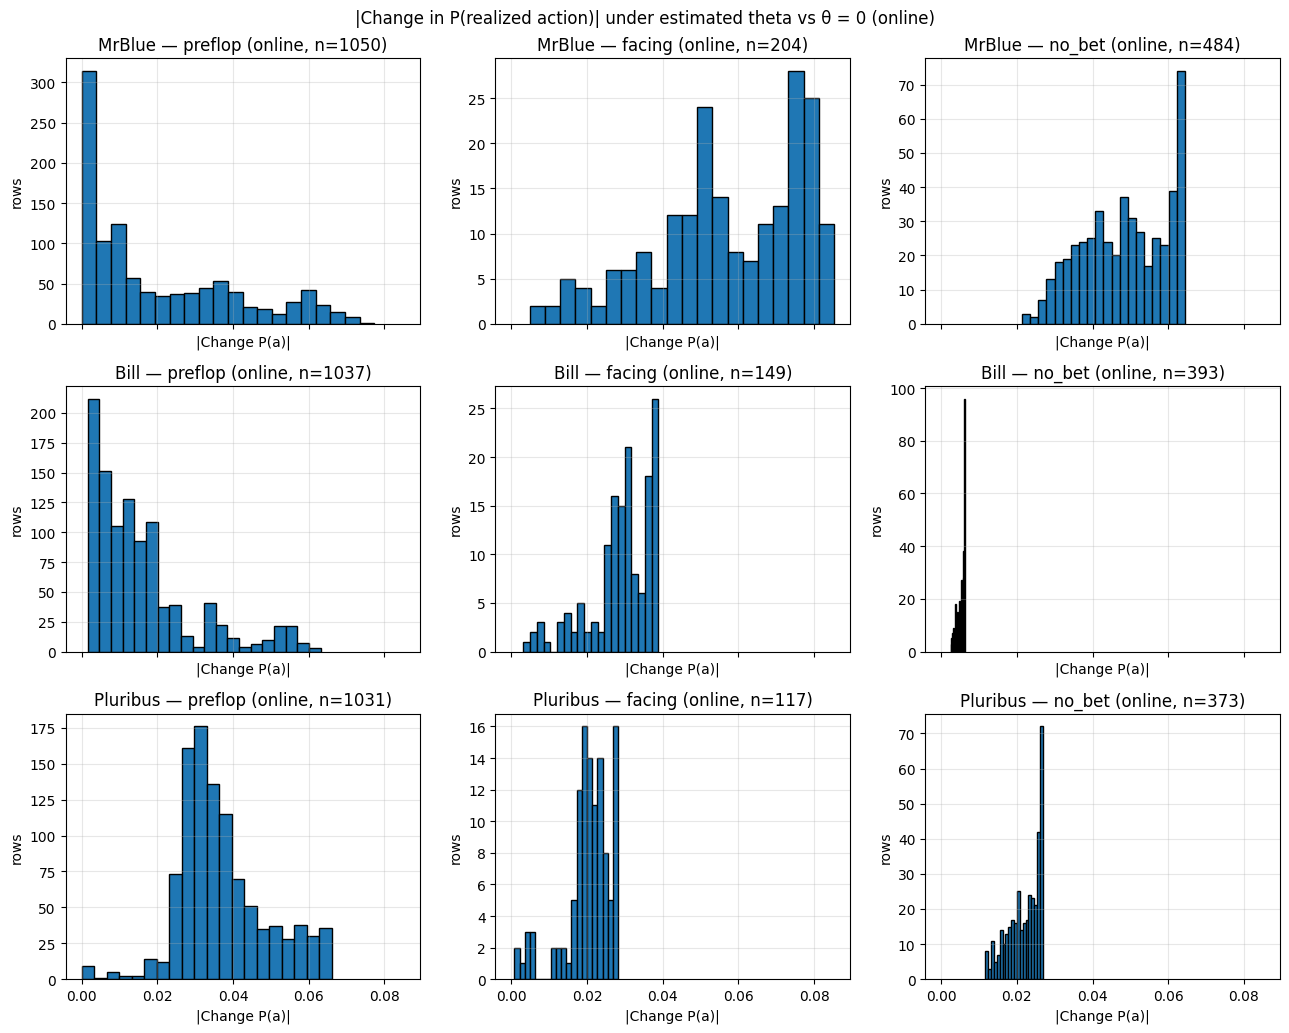

In [12]:
fig, axes = plt.subplots(len(PLAYERS), 3, figsize=(13, 3.5 * len(PLAYERS)), sharex=True)
if len(PLAYERS) == 1:
    axes = np.array([axes])
for i, p in enumerate(PLAYERS):
    for j, head in enumerate(("preflop", "facing", "no_bet")):
        ax = axes[i, j]
        s = shift_arrays[(p, "online", head)]
        if s.size == 0:
            ax.set_title(f"{p} {head} (no rows)")
            continue
        ax.hist(s, bins=20, edgecolor="black")
        ax.set_title(f"{p} — {head} (online, n={s.size})")
        ax.set_xlabel("|Change P(a)|")
        ax.set_ylabel("rows")
        ax.grid(alpha=0.3)
fig.suptitle("|Change in P(realized action)| under estimated theta vs θ = 0 (online)")
fig.tight_layout()
plt.show()